[NOTE] agent不能修改此cell
现有结论是：遗传越近的样本，跨样本基因差异越难表征
要求：
    - 按测试样本Xiu134与训练样本配对，按两个样本基因差的绝对值排序，绘制一个复合图，横轴是表达量差异的排序，从大到小，两个纵轴，一个是基因集的delta_pcc，一个是基因表达量的曲线
gene_csv: /mnt/rice/default/Workspace/yangdong/gene_expression_prediction/answer/metrices/RNA-seq_CSQ2/00_gene_level.csv
cross_csv: /mnt/rice/default/Workspace/yangdong/gene_expression_prediction/answer/metrices/RNA-seq_CSQ2/00_cross_variety_delta_summary.csv

分类信息
SampleID	SampleName	RiceType
P1	Huanghuazhan	indica
P2	Kasalath	aus
P3	Basmati	basmati
P4	IAC25	tropical japonica
P5	Tebonnet	tropical japonica
P6	Wuyungeng	temperate japonica
P7	Xiushui134	temperate japonica 
P9	Chugeng37	temperate japonica
P10	9311	indica
P11	Zhongzao35	indica
P12	IJ124	intermdiate
P13	Changmi446	indica
P14	Xiangwanxian12	indica
P16	Fengyuezhan	indica
P17	Guinongzhan	indica

In [12]:
# %% 数据加载与预处理：Xiushui134(测试) × 各训练样本 配对分析
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

GENE_CSV = "/mnt/rice/default/Workspace/yangdong/gene_expression_prediction/answer/metrices/RNA-seq_CSQ2/00_gene_level.csv"
CROSS_CSV = "/mnt/rice/default/Workspace/yangdong/gene_expression_prediction/answer/metrices/RNA-seq_CSQ2/00_cross_variety_delta_summary.csv"

TEST = "Xiushui134"
TRAINS = ["Huanghuazhan", "IAC25", "Wuyungeng", "Zhongzao35"]

# 1. 读取基因层面数据（同一 feature_id 多行取均值，与 run_evaluation.py 一致）
gene = pd.read_csv(
    GENE_CSV,
    usecols=["sample", "feature_type", "feature_id", "pred_mean", "true_mean"],
)
gene = gene[gene["feature_type"] == "gene"]
g = gene.groupby(["sample", "feature_id"])[["pred_mean", "true_mean"]].mean().reset_index()

true_pivot = g.pivot(index="feature_id", columns="sample", values="true_mean")
pred_pivot = g.pivot(index="feature_id", columns="sample", values="pred_mean")

# 2. 读取总体配对指标（cross_csv 中的 delta_pearson = 全体基因 delta_pcc）
cross = pd.read_csv(CROSS_CSV)


def get_overall_delta(train: str) -> float:
    m1 = cross[(cross["cultivar_a"] == TEST) & (cross["cultivar_b"] == train)]
    if not m1.empty:
        return float(m1["delta_pearson"].iloc[0])
    m2 = cross[(cross["cultivar_a"] == train) & (cross["cultivar_b"] == TEST)]
    return float(m2["delta_pearson"].iloc[0])


# 3. 分箱分析：按 |Δtrue| 从大到小排序，每箱计算 delta_pcc
N_BINS = 60   # 每箱约 35000/60 ≈ 580 个基因
WINDOW = 7    # 平滑窗口


def analyze_pair(train: str, n_bins: int = N_BINS):
    """按 |Δtrue| 排序分箱，每箱计算 delta_pcc（Pearson(Δpred, Δtrue)）。

    剔除 Δtrue=0 的基因：两品种表达完全相同，无差异信号可评估，
    箱内 std=0 会导致 Pearson 分母为 0 → delta_pcc=NaN → 曲线断线。
    """
    common = true_pivot[[TEST, train]].dropna().index
    common = common.intersection(pred_pivot[[TEST, train]].dropna().index)
    d_true = (true_pivot.loc[common, TEST] - true_pivot.loc[common, train]).to_numpy(float)
    d_pred = (pred_pivot.loc[common, TEST] - pred_pivot.loc[common, train]).to_numpy(float)

    keep = np.abs(d_true) > 0
    print(f"  {train}: 共有基因 n={len(d_true)} | 剔除 Δtrue=0: {int((~keep).sum())} "
          f"({(~keep).mean()*100:.1f}%) | 保留 n={int(keep.sum())}")
    d_true, d_pred = d_true[keep], d_pred[keep]

    order = np.argsort(-np.abs(d_true))   # |Δ| 从大到小
    d_true, d_pred = d_true[order], d_pred[order]
    n = len(d_true)
    bin_edges = np.linspace(0, n, n_bins + 1).astype(int)

    rows = []
    for i in range(n_bins):
        a, b = bin_edges[i], bin_edges[i + 1]
        dt, dp = d_true[a:b], d_pred[a:b]
        if len(dt) < 30:
            continue
        if np.std(dt) > 0 and np.std(dp) > 0:
            r = pearsonr(dp, dt)[0]
        else:
            r = np.nan
        rows.append({
            "bin": i,
            "pos_frac": 100.0 * (a + b) / 2 / n,   # 排序位置百分位（0 = 差异最大）
            "n": len(dt),
            "mean_abs_d_true": float(np.mean(np.abs(dt))),
            "delta_pcc": r,
        })
    info = pd.DataFrame(rows)
    info["delta_pcc_smooth"] = info["delta_pcc"].rolling(WINDOW, center=True, min_periods=1).mean()
    info["d_true_smooth"] = info["mean_abs_d_true"].rolling(WINDOW, center=True, min_periods=1).mean()
    return info, n


results = {}
for tr in TRAINS:
    info, n = analyze_pair(tr)
    results[tr] = info
    print(f"  {tr}: 整体 delta_pearson={get_overall_delta(tr):.4f} | "
          f"差异最大箱 delta_pcc={info['delta_pcc'].iloc[0]:.3f} | "
          f"差异最小箱 delta_pcc={info['delta_pcc'].iloc[-1]:.3f} | "
          f"曲线终点 x={info['pos_frac'].iloc[-1]:.1f}")

  Huanghuazhan: 共有基因 n=35127 | 剔除 Δtrue=0: 6178 (17.6%) | 保留 n=28949
  Huanghuazhan: 整体 delta_pearson=0.5961 | 差异最大箱 delta_pcc=0.600 | 差异最小箱 delta_pcc=-0.003 | 曲线终点 x=99.2
  IAC25: 共有基因 n=35171 | 剔除 Δtrue=0: 6634 (18.9%) | 保留 n=28537
  IAC25: 整体 delta_pearson=0.2853 | 差异最大箱 delta_pcc=0.230 | 差异最小箱 delta_pcc=0.043 | 曲线终点 x=99.2
  Wuyungeng: 共有基因 n=35701 | 剔除 Δtrue=0: 7167 (20.1%) | 保留 n=28534
  Wuyungeng: 整体 delta_pearson=-0.0559 | 差异最大箱 delta_pcc=-0.087 | 差异最小箱 delta_pcc=0.072 | 曲线终点 x=99.2
  Zhongzao35: 共有基因 n=33599 | 剔除 Δtrue=0: 6078 (18.1%) | 保留 n=27521
  Zhongzao35: 整体 delta_pearson=0.7533 | 差异最大箱 delta_pcc=0.754 | 差异最小箱 delta_pcc=0.031 | 曲线终点 x=99.2


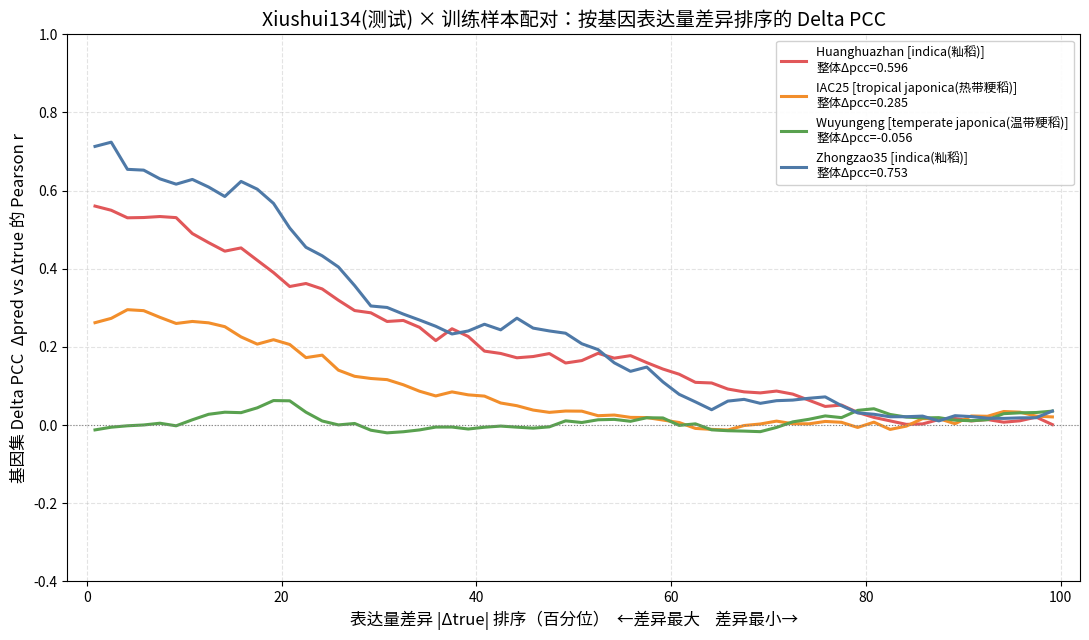

: 

In [ ]:
# %% 复合图：横轴 = |表达量差异| 排序(大→小)，纵轴 = delta_pcc
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 注册中文字体（ttc 注册后字体名取第一个子字体：Noto Sans CJK JP）
for fp in ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"]:
    if Path(fp).exists():
        fm.fontManager.addfont(fp)
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]
plt.rcParams["axes.unicode_minus"] = False

# 各品种对应亚种类型
SUBTYPE = {
    "Huanghuazhan": "indica(籼稻)",
    "IAC25": "tropical japonica(热带粳稻)",
    "Wuyungeng": "temperate japonica(温带粳稻)",
    "Zhongzao35": "indica(籼稻)",
}
COLORS = {"Huanghuazhan": "#e15759", "IAC25": "#f28e2b",
          "Wuyungeng": "#59a14f", "Zhongzao35": "#4e79a7"}

fig, ax1 = plt.subplots(figsize=(11, 6.5))

for tr in TRAINS:
    info = results[tr]
    ov = get_overall_delta(tr)
    lab = f"{tr} [{SUBTYPE[tr]}]\n整体Δpcc={ov:.3f}"
    ax1.plot(info["pos_frac"], info["delta_pcc_smooth"],
             color=COLORS[tr], lw=2.2, label=lab)

ax1.set_xlabel("表达量差异 |Δtrue| 排序（百分位）  ←差异最大    差异最小→", fontsize=12)
ax1.set_ylabel("基因集 Delta PCC  Δpred vs Δtrue 的 Pearson r", fontsize=12)

ax1.axhline(0, color="grey", lw=0.8, ls=":")
ax1.set_ylim(-0.4, 1.0)
ax1.set_xlim(-2, 102)
ax1.grid(True, ls="--", alpha=0.35)
ax1.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax1.set_title("Xiushui134(测试) × 训练样本配对：按基因表达量差异排序的 Delta PCC",
              fontsize=14)

fig.tight_layout()
plt.show()